# **Wild SHARD - CNN**

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input, Model, backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, GlobalAveragePooling1D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/AI_assignment/Wild_SHARD_Dataset/wild_shard_data.csv.csv')

# Dataset Info
- Dataset의 양, 상태, 타입을 파악해서 어떤 전처리가 필요한지 확인
  - 데이터 규모 : 약 48만개의 데이터 수
  - 칼럼(Feature) : 총 17개의 column (각 센서들(자이로, 가속도, 중력, 회전 등)를 방향(XYZ)별로 기록)
  - 결측치 여부 : 모든 컬럼의 'Non-Null Count'가 행의 총개수와 일치하는지 확인 > 결측치 없음
  - 데이터 타입 : 센서 값들이 float64로 되어있어 정규화가 즉시 가능한지 확인 + 'activity'가 object 타입임을 확인 > 라벨인코더 필요

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 483895 entries, 0 to 483894
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   AG-X       483895 non-null  float64
 1   AG-Y       483895 non-null  float64
 2   AG-Z       483895 non-null  float64
 3   Acc-X      483895 non-null  float64
 4   Acc-Y      483895 non-null  float64
 5   Acc-Z      483895 non-null  float64
 6   Gravity-X  483895 non-null  float64
 7   Gravity-Y  483895 non-null  float64
 8   Gravity-Z  483895 non-null  float64
 9   RR-X       483895 non-null  float64
 10  RR-Y       483895 non-null  float64
 11  RR-Z       483895 non-null  float64
 12  RV-X       483895 non-null  float64
 13  RV-Y       483895 non-null  float64
 14  RV-Z       483895 non-null  float64
 15  cos        483895 non-null  float64
 16  activity   483895 non-null  object 
dtypes: float64(16), object(1)
memory usage: 62.8+ MB


# Data Preprocessing

**Label 재정의**
- Label Encoder

In [4]:
# 'activity'라벨명 확인 (중복제거)
print(df['activity'].unique())

['Downstairs' 'Running' 'Sitting' 'Standing' 'Upstairs' 'Walking']


In [5]:
# 라벨인코더 : 'activity'(라벨명)이 문자열로 되어있어 숫자로 변환
le = LabelEncoder()
df['activity'] = le.fit_transform(df['activity'])
print(df['activity'].value_counts())

activity
5    90194
2    86574
1    80447
3    79947
4    74302
0    72431
Name: count, dtype: int64


In [25]:
LABELS = ['Downstairs', 'Running', 'Sitting', 'Standing', 'Upstairs', 'Walking']

**Feature Selection**
- 가속도, 자이로 센서 값만 사용하기 위해 나머지 칼럼 제거

In [7]:
df = df.drop(columns=['Gravity-X', 'Gravity-Y', 'Gravity-Z',
                      'RR-X', 'RR-Y', 'RR-Z',
                      'RV-X', 'RV-Y', 'RV-Z', 'cos'])

**★ Feature Engineering (추가)**
- 폰의 각도와 상관 없는 '흔들림 강도' feature 추가
  - 공식 : 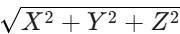 (가속도와 자이로 센서 각각에 대한 벡터 합)
  - 흔들림의 절대적인 수치만 남기기 위해 모든 값에 제곱하고, 각각 나눠져있는 방향을 하나로 합친 후, 루트로 단위(Scale) 복원
  - Why?
    - Wild dataset은 실제 일상에서의 스마트폰 데이터임 > 폰의 각도(방향)이 사람마다 다르게 되어있음.
    - 모델 입장에서는 같은 '걷기'인데도 폰의 각도(방향)에 따라 완전히 다른 데이터로 인식하게 되어 학습이 어려워질 수 있음.
  - So,
    - Magnitude를 추가하면, xyz축의 흔들림 정도가 하나의 "절대적인 에너지 값"으로 합쳐짐.
    - 방향 무시: 폰이 뒤집혀 있든 돌아가 있든, 움직임이 발생하면 Magnitude 값이 커짐.
    - 패턴 강조: 개별 xyz 축의 들쑥날쑥한 데이터보다 훨씬 단순하고 명확한 '흔들림의 패턴'이 만들어짐.

feature 생성

In [8]:
# 가속도 센서의 흔들림 강도 (Magnitude)
df['Acc_Mag'] = np.sqrt(df['Acc-X']**2 + df['Acc-Y']**2 + df['Acc-Z']**2)

# 자이로 센서의 흔들림 강도 (Magnitude)
df['AG_Mag'] = np.sqrt(df['AG-X']**2 + df['AG-Y']**2 + df['AG-Z']**2)

# 최종 feature 확인
print(df.columns)

Index(['AG-X', 'AG-Y', 'AG-Z', 'Acc-X', 'Acc-Y', 'Acc-Z', 'activity',
       'Acc_Mag', 'AG_Mag'],
      dtype='object')


feature 생성 전/후 변화 확인

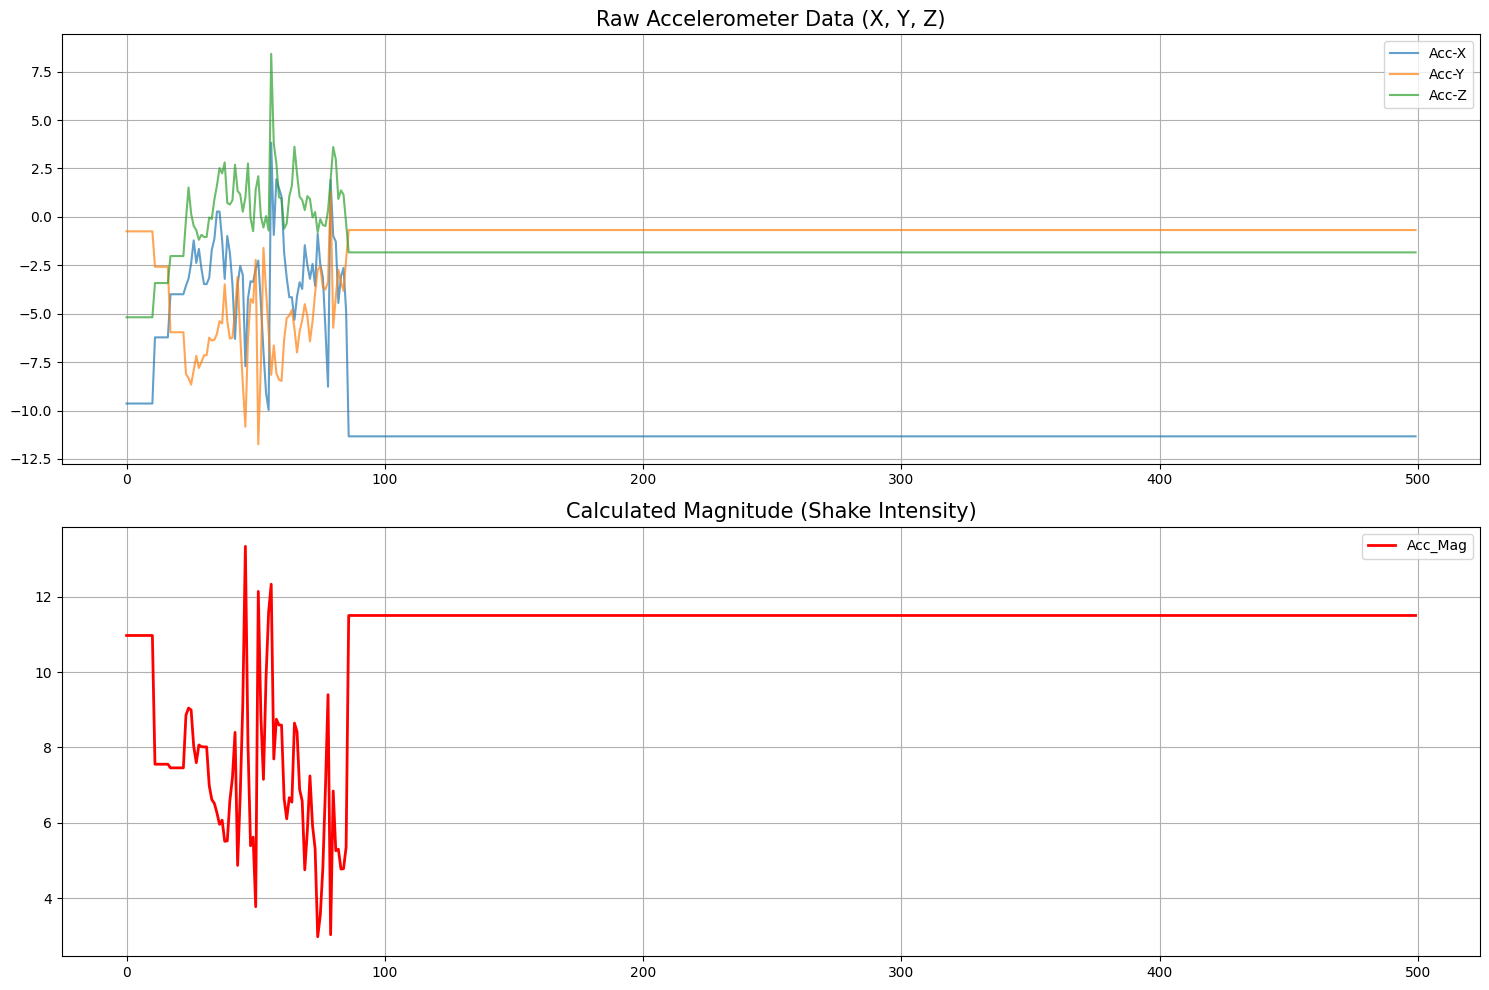

In [9]:
# 데이터가 너무 많으므로 특정 행동 데이터의 앞부분 500개 샘플만 확인
sample_data = df[df['activity'] == 5].iloc[:500]

plt.figure(figsize=(15, 10))

# 첫 번째 그래프: 가속도 센서의 X, Y, Z축 (방향에 민감)
plt.subplot(2, 1, 1)
plt.plot(sample_data['Acc-X'].values, label='Acc-X', alpha=0.7)
plt.plot(sample_data['Acc-Y'].values, label='Acc-Y', alpha=0.7)
plt.plot(sample_data['Acc-Z'].values, label='Acc-Z', alpha=0.7)
plt.title('Raw Accelerometer Data (X, Y, Z)', fontsize=15)
plt.legend(loc='upper right')
plt.grid(True)

# 두 번째 그래프: Magnitude (방향에 독립적이며, 흔들림의 세기만을 나타냄)
plt.subplot(2, 1, 2)
plt.plot(sample_data['Acc_Mag'].values, label='Acc_Mag', color='red', linewidth=2)
plt.title('Calculated Magnitude (Shake Intensity)', fontsize=15)
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

**Feature Scaling**
- Normalization (정규화) : feature 간의 값의 단위가 달라 모델이 편향되지 않도록 '평균 0, 표준편차 1'로 맞춰주는 작업
  - Why? 두 센서의 변동 폭이 다르기 때문에, 정규화하지 않으면 상대적으로 변동 폭이 큰 자이로에 과도하게 가중치를 부여할 수 있음.
  - So, 정규화를 통해 모델이 가속도처럼 미세한 진동 패턴도 잘 감지하게끔 하여 정확도를 향상시킴.
- 추가로, 약 48만 개의 대량 데이터이므로, 스케일링이 학습 속도를 높여줄 수 있음.

- 두 칼럼의 값 범위 시각화
  - 가속도(Acc): 박스(데이터의 몸통 부분)가 매우 납작하게 붙어 있음. 즉, 대부분의 데이터가 0 근처에 아주 촘촘하게 모여있다는 것.
  - 자이로(AG): 가속도에 비해 박스의 두께가 상대적으로 두꺼움. 이는 대부분 움직임의 변동 폭이 가속도보다 훨씬 크다는 것.

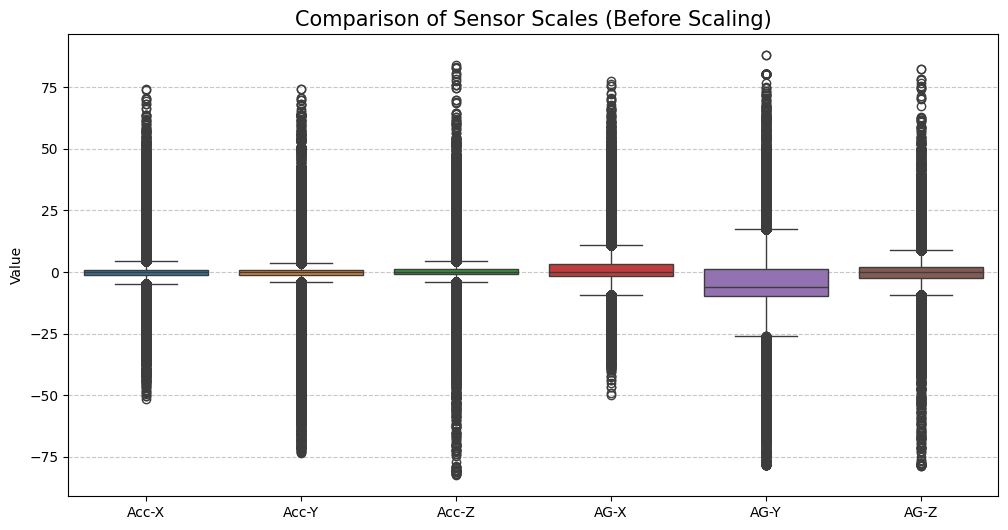

In [10]:
sensor_cols = ['Acc-X', 'Acc-Y', 'Acc-Z', 'AG-X', 'AG-Y', 'AG-Z']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[sensor_cols])
plt.title('Comparison of Sensor Scales (Before Scaling)', fontsize=15)
plt.ylabel('Value')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
# 학습에 사용할 센서 컬럼들 선택
features = ['Acc-X', 'Acc-Y', 'Acc-Z', 'AG-X', 'AG-Y', 'AG-Z', 'Acc_Mag', 'AG_Mag']
X = df[features]
y = df['activity']

# 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 다시 데이터프레임 형태로 변환 (Sliding Window을 위해)
df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled['activity'] = y.values

**Sliding Window**
- 모델에게 "이 128개의 연속된 움직임이 무슨 행동인지 맞춰봐"라고 가르치기 위해 데이터를 묶음(윈도우)으로 슬라이딩하는 작업
- Why?
  - Wild-SHARD data는 UCI HAR과 달리 window가 없는 일명 통짜 데이터셋임.
  - but, CNN은 1개의 행이 아니라, 일정 시간 동안의 '이미지' 같은 데이터를 입력으로 받기 때문에 슬라이싱 필요.
- 50%씩 overlap하는 이유 : 동작을 특정하는 데 있어 중요한 동작이 윈도우를 자르는 선에 걸려서 정보가 손실되는 것을 방지하기 위해.

In [12]:
# 윈도우 생성 함수
def create_windows(data, window_size, step_size):
    segments = []
    labels = []
    for i in range(0, len(data) - window_size, step_size):
        # 윈도우 크기만큼 데이터 추출
        window = data.iloc[i:i + window_size][features].values
        # 해당 윈도우의 최빈값(가장 많이 나온 라벨)을 정답으로 선택
        label = data.iloc[i:i + window_size]['activity'].mode()[0]
        segments.append(window)
        labels.append(label)
    return np.array(segments), np.array(labels)

# 윈도우 사이즈 128(약 2.56초만큼의 데이터), 50% 중첩(step_size=50)
X_windows, y_windows = create_windows(df_scaled, window_size=128, step_size=50)

print(f"최종 데이터 형태: {X_windows.shape}")

최종 데이터 형태: (9676, 128, 8)


학습/검증 데이터 분리

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_windows, y_windows, test_size=0.2, random_state=42, stratify=y_windows)

학습 전 최종 Data Shape 확인

In [14]:
# X_train, X_test
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("첫 번째 샘플 데이터:\n", X_train[0])

X_train shape: (7740, 128, 8)
X_test shape: (1936, 128, 8)
첫 번째 샘플 데이터:
 [[-0.10421848  0.38917091 -0.32263818 ... -0.20836038 -0.3761308
  -0.54901693]
 [-0.2667299   0.66288742 -0.39701996 ... -0.27526788 -0.14380654
  -0.80179969]
 [-0.28364792  0.78067992 -0.38055477 ... -0.17705864 -0.06399831
  -0.87913049]
 ...
 [-0.1462384   0.2355117  -0.2235844  ... -0.20366512 -0.48828331
  -0.400628  ]
 [-0.15206113  0.22211922 -0.24049345 ... -0.23144541 -0.48409484
  -0.37890416]
 [-0.10180551  0.20297197 -0.21074237 ... -0.23379304 -0.52179922
  -0.37260889]]


In [15]:
# 정답(라벨) 데이터를 원-핫 인코딩으로 변환
y_train_onehot = to_categorical(y_train)
y_test_onehot = to_categorical(y_test)

# y_train, y_test
print("y_train shape:", y_train_onehot.shape)
print("y_test shape:", y_test_onehot.shape)
print(y_train[:5])

y_train shape: (7740, 6)
y_test shape: (1936, 6)
[0 1 4 1 4]


# Model Building

In [16]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = 6

K.clear_session()

model = Sequential([
    Input(shape=input_shape),

    # 첫 번째 특징 추출
    Conv1D(128, 7, padding='same'),
    BatchNormalization(),
    ReLU(),

    # 두 번째 특징 추출 (+ MaxPooling으로 압축)
    Conv1D(256, 5, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPooling1D(2),
    Dropout(0.3),

    # 세 번째 특징 추출
    Conv1D(256, 5, padding='same'),
    BatchNormalization(),
    ReLU(),

    # 네 번째 특징 추출 (+ MaxPooling으로 압축)
    Conv1D(256, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPooling1D(2),

    # 차원 축소 및 데이터 요약 : 1차원 벡터
    GlobalAveragePooling1D(),

    # 추출된 특징들을 조합하는 은닉층
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # 최종적으로 6가지 행동 중 하나를 결정하는 출력 층
    Dense(num_classes, activation='softmax')
])

# 컴파일 설정
model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['categorical_accuracy']
        )

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 128)       │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 256)       │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 256)        │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 64, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 768,134 (2.93 MB)

 Trainable params: 765,830 (2.92 MB)

 Non-trainable params: 2,304 (9.00 KB)

None


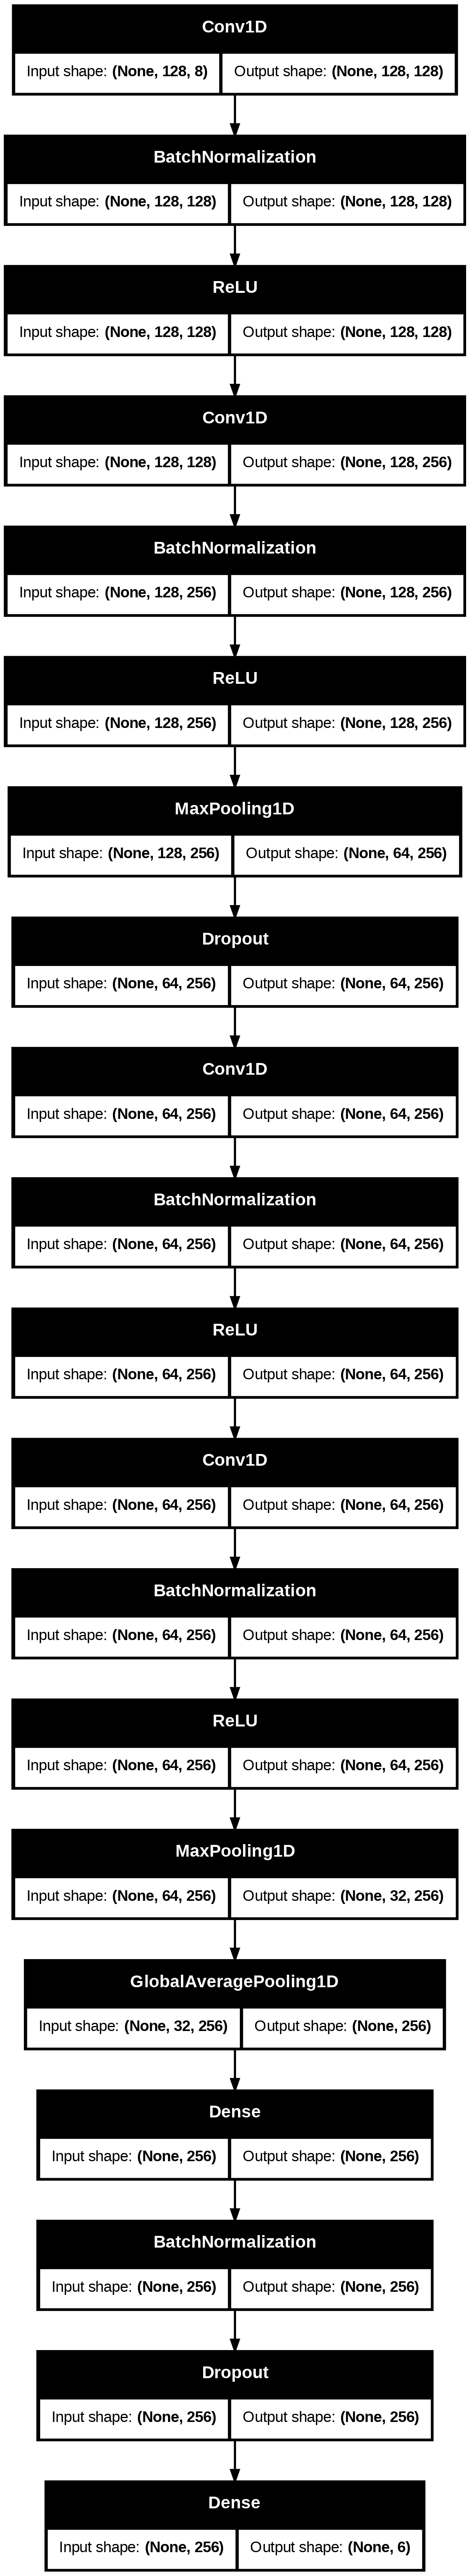

In [17]:
tf.keras.utils.plot_model(model, show_shapes=True)

callbacks

In [18]:
callbacks = [
            ModelCheckpoint(
                "Wild_CNN_best.keras",
                save_best_only=True,
                monitor="val_categorical_accuracy",
                mode='max',
                verbose=1
            ),
            EarlyStopping(
                monitor="val_categorical_accuracy",
                patience=35,
                verbose=1,
                mode='max',
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=10,
                min_lr=0.00001,
                verbose=1
            )
        ]

# Model Training

In [19]:
history = model.fit(
            X_train, y_train_onehot,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )

Epoch 1/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - categorical_accuracy: 0.6556 - loss: 0.9954
Epoch 1: val_categorical_accuracy improved from None to 0.79651, saving model to Wild_CNN_best.keras

Epoch 1: finished saving model to Wild_CNN_best.keras
194/194 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - categorical_accuracy: 0.7280 - loss: 0.7866 - val_categorical_accuracy: 0.7965 - val_loss: 0.6151 - learning_rate: 0.0010
Epoch 2/200
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.8057 - loss: 0.5650
Epoch 2: val_categorical_accuracy improved from 0.79651 to 0.85594, saving model to Wild_CNN_best.keras

Epoch 2: finished saving model to Wild_CNN_best.keras
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - categorical_accuracy: 0.8282 - loss: 0.5149 - val_categorical_accuracy: 0.8559 - val_loss: 0.5209 - learning_rate: 0.0010
Epoch 3/200
188/194 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.8508 - loss: 0.4621
Epoch 3: val_categorical_accuracy improved from 0.85594

# Model Evaluation

In [20]:
# best 기록 확인
model = tf.keras.models.load_model("Wild_CNN_best.keras")

train_loss, train_acc = model.evaluate(X_train, y_train_onehot, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model.evaluate(X_test, y_test_onehot, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.64%
Training loss: 0.0180
Test accuracy: 97.93%
Test loss: 0.0877


In [21]:
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# f1-score 분류 리포트
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9860    0.9724    0.9792       290
           1     0.9904    0.9657    0.9779       321
           2     0.9775    0.9971    0.9872       348
           3     0.9782    0.9843    0.9812       319
           4     0.9862    0.9596    0.9727       297
           5     0.9624    0.9917    0.9768       361

    accuracy                         0.9793      1936
   macro avg     0.9801    0.9785    0.9792      1936
weighted avg     0.9795    0.9793    0.9793      1936



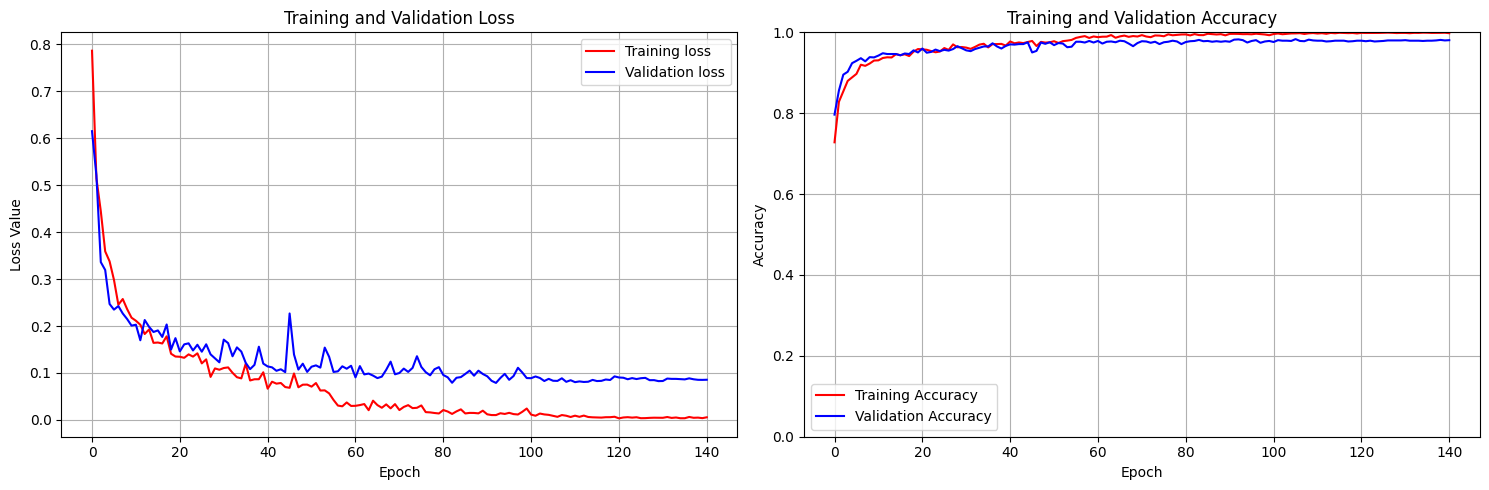

In [22]:
# loss / accuracy 그래프
train_loss = history.history['loss']
train_accuracy = history.history['categorical_accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.ylim([0.0, 1.0])
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

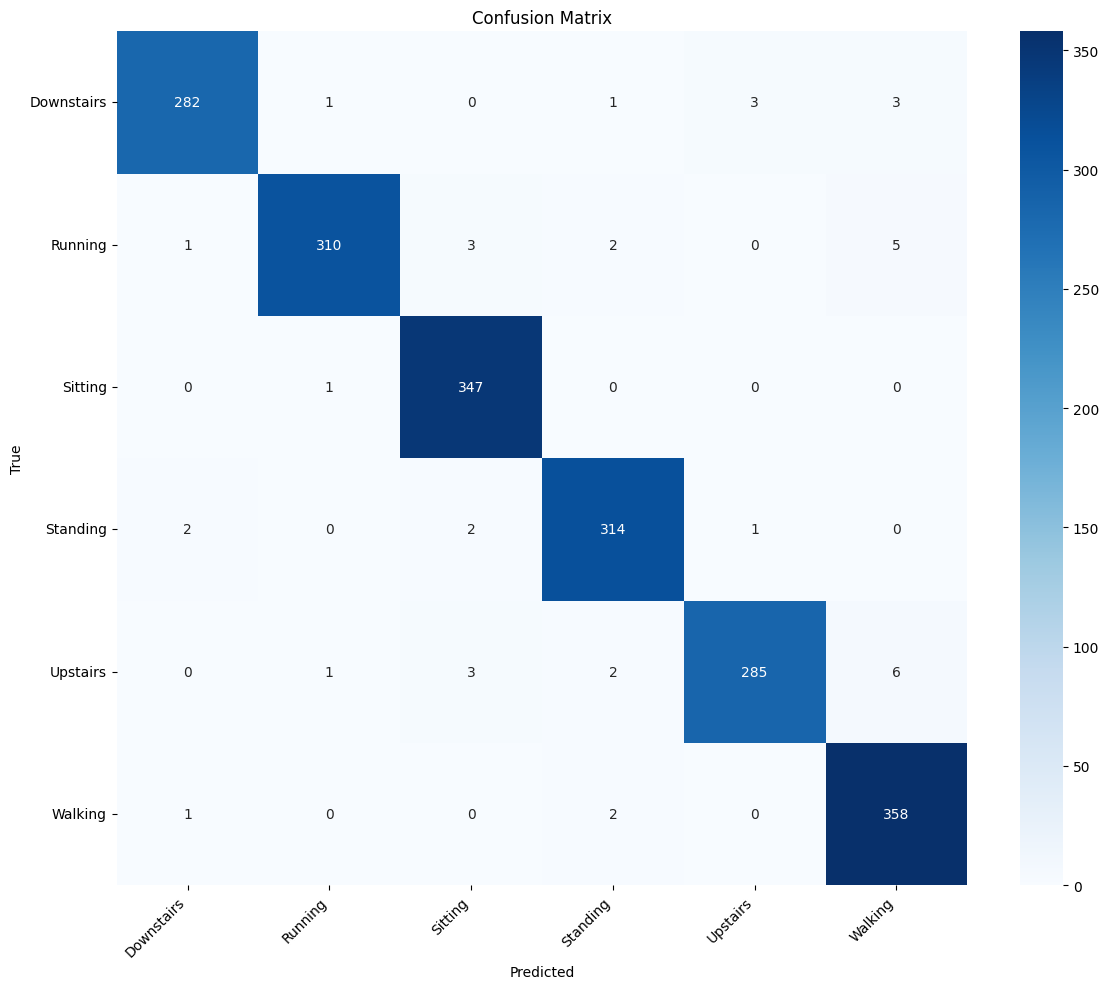

In [28]:
# 혼동행렬(히트맵)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS,
            yticklabels=LABELS)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()